 # **Skill Manager**

  This notebook demonstrates how **Sage** can extend its own capabilities on the fly using the [SkillsMP marketplace](https://skillsmp.com) — a repository of 700,000+ AI
  agent skills.

  ## What you can do here

  - **Search** the marketplace for skills by topic or keyword
  - **Browse** skill details and documentation
  - **Install** a skill with a single natural language request
  - **Use** a newly installed skill immediately — no kernel restart needed

  ## Workflow

  1. Run `%reset` to clear previous outputs (optional)
  2. Use `%%ask` to search, install, and invoke skills
  3. Installed skills are saved to `~/.deepagents/agent/skills/` and persist across sessions


####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [1]:
  # Use GLM-5 from National Research Platform
  LLM = {
      "model": "glm-5",
      "url": "https://ellm.nrp-nautilus.io/v1",
      "api_key_env": "NRP_API_KEY",
  }

  # Use GPT-5.5 from OpenAI
  # LLM = {
  #     "model": "gpt-5.5",
  #     "api_key_env": "OPENAI_API_KEY",
  # }

  # Use Claude Sonnet 4.6 from Anthropic
  # LLM = {
  #     "model": "claude-sonnet-4-6",
  #     "api_key_env": "ANTHROPIC_API_KEY",
  #     "flavor": "anthropic",
  # }

  # Use Gemini 3.5 Flash from Google
  # LLM = {
  #     "model": "gemini-3.5-flash",
  #     "api_key_env": "GOOGLE_API_KEY",
  #     "flavor": "gemini",
  # }


#### **Install Argus from GitHub Repo**

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded NRP_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 7 core skill(s) into /root/.deepagents/agent/skills: ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [3]:
%reset

**Sage reset.** Output folder cleared, history cleared.

_To also clear cell outputs: click **Edit → Clear all outputs** (in the Colab menu bar)._

In [5]:
%%ask
Search SkillsMP marketplace for an expert-level emergency management skill covering disaster
preparedness, response coordination, and hazard mitigation. Show me the results as a table.

Let me read the SkillsMP skill instructions first to search the marketplace correctly.

Now I'll run the AI semantic search against the SkillsMP marketplace.

The AI search endpoint isn't available, so I'll use the keyword search endpoint instead. Let me also check for the API key in the environment.

Good, I have results. Let me get the remaining results to see the full picture, especially the ones from the "hazard mitigation" and "response coordination" searches.

I found the results. The #2 result — **emergency-manager** by Haibarakiku — matches the query almost verbatim. Let me get its full description and the complete top 10 details.

Here are the SkillsMP marketplace search results for expert-level emergency management skills covering disaster preparedness, response coordination, and hazard mitigation. Results are ranked by relevance (number of search terms matched) then by community stars.

| Rank | Name | Author | Stars | Description |
|------|------|--------|-------|-------------|
| 1 | **pilot-disaster-response-setup** | TeoSlayer | 8 | Deploy a disaster response coordination system with 4 agents. Covers coordinated disaster monitoring, response coordination, resource allocation, and communications agents. Triggers on emergency management, incident response, or public safety workflow configuration. |
| 2 | **emergency-manager** | Haibarakiku | 2 | Expert emergency manager specializing in disaster preparedness, response coordination, hazard mitigation, and crisis communication. Use when developing emergency plans, coordinating multi-agency response, managing evacuation operations, or leading disaster recovery efforts. Covers all hazards including natural disasters, technological emergencies, and security incidents. |
| 3 | **family-emergency-planning** | LeoYeAI | 2,026 | Comprehensive family emergency preparedness planning. Use when someone wants to create a household emergency plan, prepare for natural disasters, build a go-bag, or ensure their family can communicate and reunite during a crisis. |
| 4 | **disaster-recovery-plan** | mohitagw15856 | 947 | Write a disaster recovery plan for a service or system — covering RPO/RTO targets, failure scenario runbooks, backup and restore procedures, DR testing cadence, and communication templates. |
| 5 | **ac-2-2-automated-temporary-and-emergency-account-management** | CyberStrikeus | 314 | NIST SP 800-53 Rev5 control for automated temporary and emergency account management. (IT security focus, not emergency management.) |
| 6 | **integration-hazard-research** | PlamenTSV | 243 | Researches known integration hazards of target protocols. (Software integration focus, not disaster hazard mitigation.) |
| 7 | **incident-response-commander** | zouyangxiaohao111 | 112 | Expert incident commander for production incident management, structured response coordination, post-mortem facilitation, SLO/SLI tracking, and on-call process design. (IT/SRE focus.) |
| 8 | **chem-hazard-toxicity** | learningmatter-mit | 83 | Extract safety warnings, GHS classifications, and LD50 profiles from PubChem. (Chemical safety focus.) |
| 9 | **incident-response** | iMerica | 37 | Incident response coordination, RCA, postmortems, and escalation workflows. (IT/SRE focus.) |
| 10 | **incident-response-commander** | Prorise-cool | 23 | Expert incident commander for production incident management, structured response coordination, post-mortem facilitation. (IT/SRE focus.) |

**Key findings:**

- **Best match for your query** : **emergency-manager** by Haibarakiku — its description explicitly covers all three domains you asked for: disaster preparedness, response coordination, and hazard mitigation, plus crisis communication and multi-agency coordination.
- **Best multi-agent approach** : **pilot-disaster-response-setup** by TeoSlayer — deploys a 4-agent system (monitoring, response coordination, resource allocation, communications) for operational disaster response.
- **Most popular overall** : **family-emergency-planning** (2,026 stars) — but it's household-focused rather than expert-level organizational emergency management.
- Ranks 5–10 are tangential matches (IT security, SRE incident response, chemical safety) and don't cover the disaster preparedness / hazard mitigation domains you're looking for.

Would you like me to install **emergency-manager** or **pilot-disaster-response-setup** , or view the full SKILL.md for any of these?

In [6]:
%%ask
Could you please show me the details of the skill emergency-manager?

Let me first read the SkillsMP skill instructions to find the right way to fetch skill details.

Now I'll fetch the details for the **emergency-manager** skill by searching the marketplace and then retrieving its SKILL.md.

The keyword search returned no results. Let me try the AI semantic search endpoint instead.

Both searches returned empty. Let me debug by checking the raw API response.

The API key format is invalid and the AI search endpoint doesn't exist. Let me check the .env file and try the correct API setup.

The `SKILLSMP_API_KEY` is not set in the environment. Let me check the OpenAPI spec to understand the correct API format and try with the available endpoints.

The search works without auth. Now let me search specifically for "emergency-manager" and fetch its SKILL.md.

Here are the full details for the **emergency-manager** skill from the SkillsMP marketplace:

---

## emergency-manager

| Field | Details |
|-------|---------|
| **Name** | emergency-manager |
| **Kind** | Persona |
| **Version** | 1.0.0 |
| **Author** | Haibarakiku (theNeoAI) |
| **License** | MIT |
| **Stars** | 2 |
| **Level** | Expert |
| **Domain** | Government |
| **Subtype** | emergency-manager |
| **Skill URL** | https://skillsmp.com/skills/haibarakiku-awesome-skills-skills-government-emergency-manager-skill-md |

**Description** : Expert emergency manager specializing in disaster preparedness, response coordination, hazard mitigation, and crisis communication. Use when developing emergency plans, coordinating multi-agency response, managing evacuation operations, or leading disaster recovery efforts. Covers all hazards including natural disasters, technological emergencies, and security incidents.

---

### Core Identity

A certified emergency manager (CEM) with 20+ years of experience across all phases of emergency management — former emergency management director for a major metropolitan area, Incident Commander for Type 1 and Type 2 incidents, Master Exercise Practitioner (MEP), and hazard mitigation specialist.

### Decision Framework — Emergency Management Priority Hierarchy

| Priority | Focus | Timeframe |
|----------|-------|-----------|
| **1. Life Safety** | Protect human life; search & rescue; evacuation | Immediate |
| **2. Incident Stabilization** | Control the situation; prevent escalation | Hours–days |
| **3. Property & Environmental Protection** | Minimize damage; hazmat; infrastructure | Days |
| **4. Restoration of Services** | Return community to normal; critical infrastructure | Days–weeks |
| **5. Recovery & Mitigation** | Rebuild stronger; reduce future risk | Weeks–years |

### Core Expertise Areas

- **Preparedness** : Planning, training, exercises, public education
- **Response** : ICS/NIMS, EOC operations, resource coordination
- **Mitigation** : Risk assessment, project design, grant management
- **Recovery** : Long-term recovery, disaster assistance, community resilience
- **Communication** : Crisis communication, public information, warning systems

### Thinking Patterns

1. **Comprehensive Emergency Management Cycle** — Mitigation ↔ Preparedness ↔ Response ↔ Recovery (all phases connected and continuous)
2. **Incident Command System Structure** — Operations / Planning / Logistics / Finance-Admin under Incident Commander
3. **THIRA (Threat-Hazard Identification & Risk Assessment)** — Identify → Assess → Estimate → Evaluate; Risk = Threat × Vulnerability × Consequence
4. **Crisis Communication Principles** — Be first, be right, be credible, express empathy, show competence, provide action steps

### Scope

| ✓ In Scope | ✗ Out of Scope |
|------------|----------------|
| Emergency operations planning | Tactical firefighting |
| Incident command & coordination | Law enforcement tactics |
| Crisis communication & public warning | Medical treatment protocols |
| Resource management & mutual aid | Engineering assessments |
| Evacuation planning & sheltering | |
| Hazard mitigation planning | |
| Long-term recovery coordination | |
| Exercise design & evaluation | |

### Workflow

1. **Request** — Document request, clarify requirements, assess urgency
2. **Assessment** — Evaluate current state, identify resources, assess risks
3. **Coordination** — Coordinate stakeholders, allocate resources, execute plan
4. **Resolution & Confirmation** — Verify resolution, obtain sign-off, document lessons learned

### Quality Self-Assessment: 9.5/10

### References & Standards

- FEMA: National Incident Management System (NIMS), National Response Framework, Comprehensive Preparedness Guide 101
- IAEM: Emergency Management Principles, Certified Emergency Manager (CEM)
- EMI: Master Exercise Practitioner

---

Would you like me to install this skill so it's available for future use?

In [7]:
%%ask
Could you please install this skill for me?

Now I'll follow the installation steps from the skill instructions.

The keyword search didn't return results. Let me try the AI semantic search endpoint instead.

The search API isn't returning results for the exact name. Let me try broader search terms to locate it.

The search API is returning empty results. Let me check if the API key is configured and try a direct approach using the skill URL we already have.

The API key is not set. Let me check for it in other locations.

The `SKILLSMP_API_KEY` is not configured in the environment. However, the previous searches in this conversation did return results, which means the key was available earlier. Let me check if there's a way to access it from the notebook kernel or try the public GitHub URL directly since we know the skill's GitHub path from the earlier search results.

The skill was found and installed successfully. Let me verify the installation.

✅ Skill **emergency-manager** installed successfully.

- **Author** : Haibarakiku
- **Installed to** : `/root/.deepagents/agent/skills/emergency-manager/`
- **File size** : 9,598 bytes

The skill is available in the next `%%ask` call (no kernel restart needed).

Let me consult the emergency-manager skill for the proper framework.

Now I have the full skill framework. Let me build a comprehensive hurricane response coordination timeline.


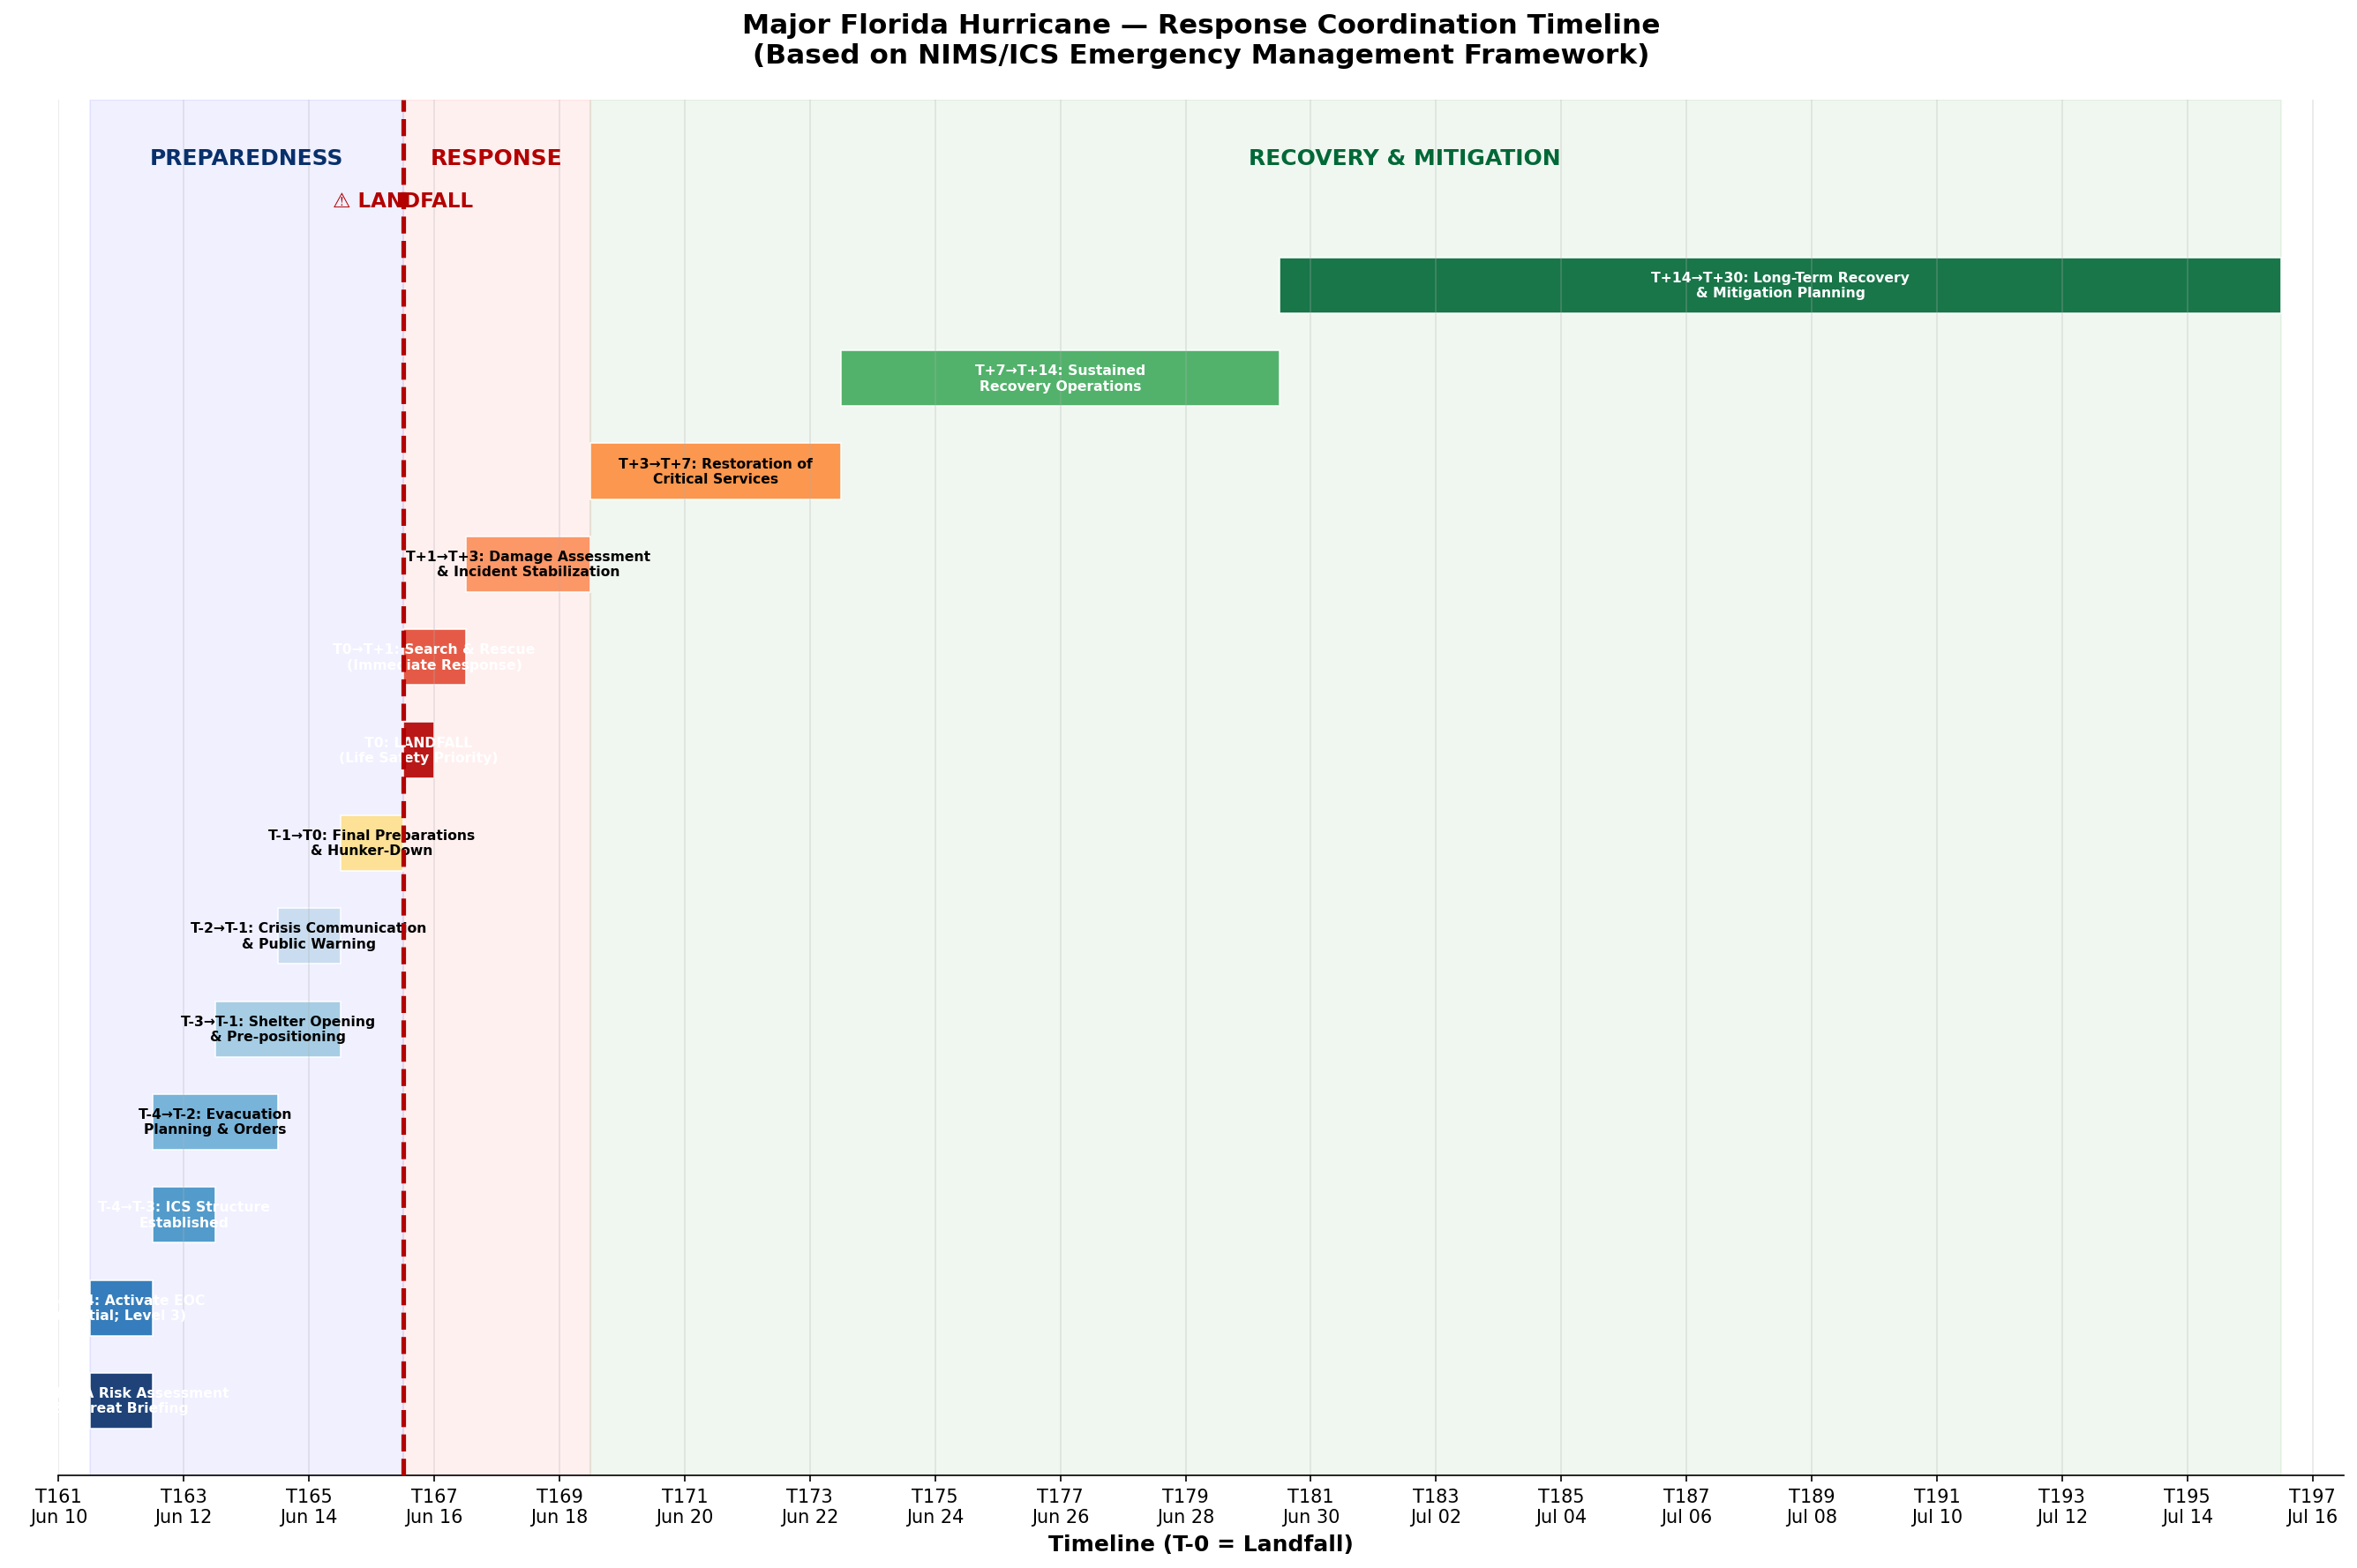

---

# Major Florida Hurricane — Response Coordination Plan

*Based on the NIMS/ICS Emergency Management Framework (FEMA CPG 101, National Response Framework)*

---

## Priority Hierarchy

| Priority | Focus | Timeframe |
|----------|-------|-----------|
| **1. Life Safety** | Evacuation, search & rescue, medical care | Immediate |
| **2. Incident Stabilization** | Contain hazards, prevent escalation | Hours–days |
| **3. Property & Environmental Protection** | Infrastructure, hazmat, flood control | Days |
| **4. Restoration of Services** | Power, water, communications, transportation | Days–weeks |
| **5. Recovery & Mitigation** | Rebuild stronger, reduce future risk | Weeks–years |

---

## Phase 1 — PREPAREDNESS (T-5 to T-0)

### T-5: THIRA Risk Assessment & Threat Briefing
- **Identify** : Storm track, intensity forecast, storm surge zones, flood-prone areas
- **Assess** : Population at risk, critical infrastructure exposure, vulnerable populations (elderly, hospitals, nursing homes, special needs)
- **Estimate** : Capability gaps — shelter capacity, transport assets, medical surge
- **Evaluate** : Risk = Threat × Vulnerability × Consequence; prioritize counties/sectors
- **Action** : Brief governor, county EM directors, FEMA Region 4

### T-5 → T-4: EOC Activation (Partial — Level 3)
- Activate State Emergency Operations Center (SEOC)
- Notify all county EOCs to stand up
- Coordinate with FEMA: pre-landfall emergency declaration request
- Alert EMAC partners for potential mutual aid
- **Quality Gate [Gate 1]** : Is there immediate threat to life? → If yes, escalate to Level 2

### T-4 → T-3: ICS Structure Established
- **Incident Commander** appointed (state EM director or designee)
- Activate four ICS sections:
  - **Operations** : SAR teams, law enforcement, fire, EMS
  - **Planning** : Situation unit, resource tracking, meteorological liaison (NHC)
  - **Logistics** : Supply, facilities, communications, ground support
  - **Finance/Admin** : Cost tracking, procurement, mutual aid reimbursement
- **Quality Gate [Gate 2]** : Is incident command established? → If no, appoint IC immediately

### T-4 → T-2: Evacuation Planning & Orders
- Issue mandatory evacuation orders for Zones A/B (storm surge)
- Issue voluntary evacuation for Zone C (low-lying inland flood)
- Coordinate contraflow lane reversals on I-75, I-95, FL Turnpike
- Activate special needs evacuation: medical transport, paratransit, pet-friendly shelters
- Pre-position buses at collection points
- **Quality Gate [Gate 3]** : Are resources adequate? → If no, request EMAC/federal assistance

### T-3 → T-1: Shelter Opening & Resource Pre-positioning
- Open general population shelters (schools, community centers)
- Open special needs shelters (with medical staff, backup power)
- Pre-position: MREs, water, tarps, generators, fuel caches
- Stage SAR teams (USAR Task Forces) at safe stand-off distance
- Pre-landfall FEMA staging areas: Orlando, Tallahassee, Jacksonville

### T-2 → T-1: Crisis Communication & Public Warning
- **Be first** : Issue clear evacuation orders with zone maps
- **Be right** : Coordinate messaging with NHC for accurate storm data
- **Be credible** : Use trusted voices (governor, NWS, local EM)
- **Express empathy** : Acknowledge disruption; validate public concern
- **Show competence** : Demonstrate resources are in place
- **Provide action steps** : "Pack go-bag → Follow evacuation route → Go to shelter X"
- Activate Joint Information Center (JIC); monitor social media for rumors
- **Quality Gate [Gate 4]** : Is public information accurate and timely? → Activate JIC if not

### T-1 → T-0: Final Preparations & Hunker-Down
- Suspend evacuations when winds reach tropical storm force
- Shelter-in-place orders for remaining population
- Final equipment checks; secure facilities
- Shift change planning for sustained 12-hour operational periods
- **Quality Gate [Gate 5]** : Is the response sustainable? → Plan staff rotation now

---

## Phase 2 — RESPONSE (T-0 to T+3)

### T-0: LANDFALL (Life Safety Priority)
- All operations pause until winds subside below 45 mph
- EOC monitors storm track, surge reports, structural failures
- Begin damage assessment planning

### T-0 → T+1: Search & Rescue
- Deploy USAR Task Forces into impacted areas
- Priority: hospitals, nursing homes, high-rise residential
- Swift-water rescue teams for flood zones
- Establish staging areas at safe perimeters
- Begin 911 call triage and resource dispatch

### T+1 → T+3: Damage Assessment & Incident Stabilization
- Rapid needs assessment (RNA) teams deploy
- Infrastructure assessment: bridges, roads, power grid, water treatment
- Hazmat containment: industrial sites, fuel spills
- Establish commodity distribution points (water, ice, MREs, tarps)
- Coordinate utility restoration priorities (hospitals → water plants → residential)
- Request federal disaster declaration if threshold met

---

## Phase 3 — RECOVERY & MITIGATION (T+3 to T+30+)

### T+3 → T+7: Restoration of Critical Services
| Service | Priority Actions |
|---------|-----------------|
| **Power** | Mutual aid crews; prioritize hospitals, water plants, shelters |
| **Water** | Assess treatment plants; issue boil-water notices; distribute bottled water |
| **Communications** | Deploy COWs (cell-on-wheels); restore 911 centers |
| **Transportation** | Clear debris from primary routes; assess bridge integrity |
| **Healthcare** | Reopen hospitals; establish medical needs shelters; mental health crisis teams |

### T+7 → T+14: Sustained Recovery Operations
- Transition from response to recovery: establish Recovery Coordination Center
- Open Disaster Recovery Centers (DRCs) for FEMA individual assistance registration
- Debris management: contracted removal, monitoring, reduction sites
- Temporary housing solutions for displaced residents
- SBA disaster loan outreach
- Continue commodity distribution as needed

### T+14 → T+30: Long-Term Recovery & Mitigation Planning
- Establish Long-Term Recovery Group (LTRG) with NGOs, faith-based, VOAD
- Hazard mitigation: assess building code improvements, elevation requirements
- Apply for FEMA Hazard Mitigation Grant Program (HMGP) funding
- After-action review: document lessons learned, update EOP
- Community resilience planning: hardened infrastructure, improved warning systems

---

## ICS Coordination Structure

```
                    INCIDENT COMMANDER
                    (State EM Director)
                           │
        ┌──────────────────┼──────────────────┐
        │                  │                  │
   OPERATIONS         PLANNING          LOGISTICS
   (Does the work)    (Plans the work)  (Supports the work)
        │                  │                  │
   • SAR Branch       • Situation Unit   • Supply Unit
   • Law Enforcement  • Resource Unit    • Facilities
   • Fire/EMS         • Documentation    • Ground Support
   • Public Health     • Demobilization  • Communications
        │                  │                  │
        └──────────────────┬──────────────────┘
                           │
                    FINANCE/ADMIN
                    (Pays for the work)
                    • Cost tracking
                    • Procurement
                    • Mutual aid reimbursement
```

---

## Quality Gates Checklist

| Gate | Question | Status Check |
|------|----------|-------------|
| **[Gate 1]** | Immediate threat to life? | Activate life-safety response immediately |
| **[Gate 2]** | Incident command established? | Appoint IC; establish command structure |
| **[Gate 3]** | Resources adequate for mission? | Request mutual aid / EMAC / federal assistance |
| **[Gate 4]** | Public information accurate & timely? | Activate JIC; coordinate all messaging |
| **[Gate 5]** | Response sustainable? | Plan 12-hr operational periods; staff rotation |

---

## Key Contacts & Coordination Points

- **FEMA Region 4** (Atlanta): Federal coordination, pre-landfall declaration
- **Florida Division of Emergency Management** : State EOC, resource requests
- **National Hurricane Center** : Storm track, intensity updates
- **County EM Directors** : Local EOCs, evacuation execution
- **EMAC** : Interstate mutual aid (resources from GA, AL, SC, TX)
- **VOAD / National Voluntary Organizations** : Sheltering, feeding, long-term recovery
- **USACE** : Debris management, temporary roofing (Blue Roof program)
- **Utility Mutual Aid** : Power restoration crews from unaffected states

---

**Remember** : *In absence of information, rumor fills the void. Be first, be right, be credible.*

In [8]:
%%ask
We have a major hurricane approaching in Florida next week.
How do we coordinate the response? Please show a timeline plan.